# Day 3 — Dimensionality Reduction with PCA

This notebook applies Principal Component Analysis (PCA) to the **Breast Cancer Wisconsin dataset** built into scikit-learn. The dataset has 569 samples and 30 numeric features describing characteristics of cell nuclei, which is high-dimensional enough to make the curse of dimensionality and the benefit of PCA clearly visible, and it also comes with a known binary label (malignant / benign) that can be used to color a 2D projection later on.

The goal of this notebook is not just to run PCA, but to explain, at each step, why that step is necessary and what the resulting chart is telling us.


## 3.1 The Curse of Dimensionality

Real datasets often contain dozens or hundreds of features, and this dataset is a good example with 30 of them. As the number of features grows, several problems appear:

- Data becomes **sparse**: the same number of samples has to "cover" a much larger space, so points end up far apart from each other.
- **Distances lose meaning**: in high dimensions, the difference between the nearest and farthest neighbor of a point shrinks, which hurts distance-based methods.
- **Overfitting becomes easier**: with more features than the data can reliably support, models start fitting noise instead of signal.
- **Visualization becomes impossible** beyond 3 dimensions, so it is hard to even look at the data to understand it.

Dimensionality reduction addresses this by compressing many correlated features into a much smaller set of new features, while keeping as much of the original information as possible.

## 3.2 What PCA Does

Principal Component Analysis finds new axes — the **principal components** — that point in the directions of greatest variance in the data. The first component captures the most variance possible, the second captures the next most variance while staying at a right angle to the first, and so on. Each component is a linear combination of the original features, built using the same linear-algebra ideas (projections and eigenvectors) covered in Week 2.

By keeping only the first few components instead of all 30 original features, we reduce the dimensionality of the data while retaining most of the information it contains.

## 3.3 Explained Variance

The key output of PCA is the **explained variance ratio**: how much of the total variance in the data each component accounts for. Summing the ratios of the first *k* components tells us how much of the original information is retained after keeping only those *k* components. A common rule of thumb is to keep enough components to retain about **95%** of the total variance, which is the threshold used later in this notebook.

PCA requires the data to be scaled first, because it is a variance-based method: a feature with a naturally larger numeric range would dominate the variance calculation and appear artificially important. `StandardScaler` is applied before PCA for exactly this reason.

## 3.4 When to Use PCA

PCA is mainly useful for three things:

1. **Compressing features** to speed up and stabilize downstream models.
2. **Reducing overfitting** by removing redundant or correlated features.
3. **Reducing data to 2D or 3D** so it can be plotted and inspected visually.

The trade-off is that the new components are combinations of the original features, so they lose the direct interpretability that the original columns had — a principal component does not correspond to a single measurable quantity like "radius" or "texture" anymore.

## Hands-On Lab: Reducing Dimensions with PCA

The lab is carried out on the Breast Cancer Wisconsin dataset for the reasons explained above: it is high-dimensional (30 features), it needs scaling since its features are on different numeric scales, and it has a ground-truth label that can be used to check, at the end, whether the reduced representation still separates the two classes visually.

### Step 1 — Scale the Data

Before doing anything else, the 30 features are scaled with `StandardScaler` so that every feature has mean 0 and standard deviation 1. This step is done first, and separately from PCA itself, so that the effect of scaling can be checked directly on the data before PCA is applied to it. Without this step, PCA would be biased toward whichever original feature happens to have the largest numeric range, not the one that is actually most informative.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = load_breast_cancer()
x = data.data
y = data.target
feature_names = data.feature_names

print("Original data shape (samples, features):", x.shape)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Mean of first column after scaling:", round(x_scaled[:, 0].mean(), 4))
print("Std of first column after scaling:", round(x_scaled[:, 0].std(), 4))


Original data shape (samples, features): (569, 30)
Mean of first column after scaling: -0.0
Std of first column after scaling: 1.0


The mean of the first column is (effectively) 0 and its standard deviation is exactly 1, confirming that scaling worked as intended across all 30 features. The data is now on a comparable scale and ready for PCA.

### Step 2 & 3 — Fit PCA on All Components and Choose How Many to Keep

`PCA()` is first fit with no limit on the number of components, purely to inspect how variance accumulates as components are added. Plotting the **cumulative explained variance** against the number of components shows the diminishing returns of each additional component, and makes it possible to read off, visually, how many components are needed to cross the 95% variance threshold before committing to a final, smaller number of components.

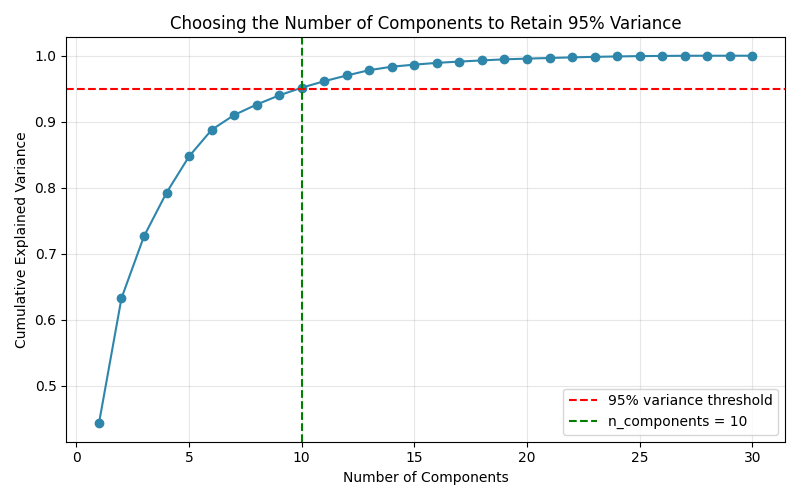

Explained variance ratio (first 5 components): [0.4427 0.1897 0.0939 0.066  0.055 ]
Components needed to reach 95%: 10


In [2]:
pca_full = PCA().fit(x_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_95 = np.argmax(cumulative >= 0.95) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker='o', color='#2E86AB')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% variance threshold')
plt.axvline(x=n_95, color='green', linestyle='--', label=f'n_components = {n_95}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Choosing the Number of Components to Retain 95% Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Explained variance ratio (first 5 components):", np.round(explained[:5], 4))
print(f"Components needed to reach 95%: {n_95}")


**Reading the chart:** the curve rises steeply for the first few components — the first component alone explains about 44% of the variance, and the first two together explain about 63% — then flattens out, which is the typical "diminishing returns" shape of a cumulative explained variance plot. The dashed red line marks the 95% threshold, and the dashed green line shows where the curve first crosses it, at **10 components**. This means that reducing the original 30 features down to just 10 principal components keeps about 95% of the information in the dataset, which is the justification for choosing `n_components = 10` if the goal were to build a model on the reduced data: it is a large reduction in dimensionality (30 → 10) with only a small, controlled loss of information (~5%).

### Step 4 — Reduce to 2 Components and Visualize

For visualization specifically, the number of components has to be 2 (or 3), regardless of the 95% rule, since that is the most that can be plotted on a flat chart. The data is projected down to 2 components and plotted, coloring each point by its known diagnosis label (malignant or benign) to check whether the classes are still visually separable after this aggressive reduction from 30 dimensions to 2.

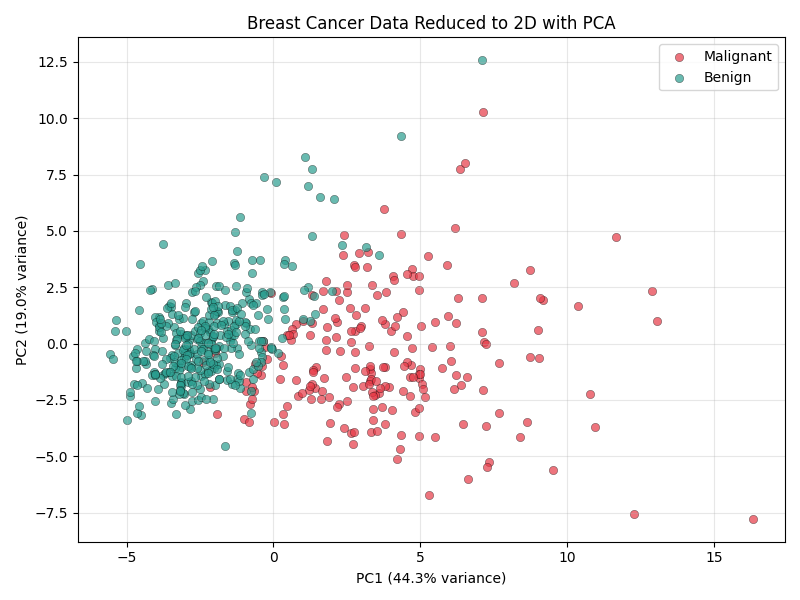

Variance retained with 2 components only: 63.24%


In [3]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
colors = ['#E63946', '#2A9D8F']
labels = ['Malignant', 'Benign']

for class_value, color, label in zip([0, 1], colors, labels):
    mask = y == class_value
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=label, alpha=0.7, edgecolors='k', linewidths=0.3)

var1, var2 = pca_2d.explained_variance_ratio_
plt.xlabel(f'PC1 ({var1*100:.1f}% variance)')
plt.ylabel(f'PC2 ({var2*100:.1f}% variance)')
plt.title('Breast Cancer Data Reduced to 2D with PCA')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Variance retained with 2 components only: {(var1+var2)*100:.2f}%")


**Reading the chart:** even though only 63.24% of the total variance is retained with just 2 components (well below the 95% target from Step 3), the malignant and benign points still form two largely separated clouds along PC1, with only a modest amount of overlap near the boundary. This shows that most of the class-relevant signal in the original 30 features is concentrated in the direction of highest variance, which is why a 2D PCA plot is still a useful, if imperfect, tool for a first visual inspection of the data — it is meant for visualization, not for feeding into a final model, which is why Step 3 chose 10 components instead of 2 for that purpose.

### Step 5 — What the Reduction Preserved and What It Cost

**What was preserved:**
- With 10 components, about **95%** of the total variance in the original 30 features is retained, so most of the information that distinguishes one sample from another is still present.
- Even with only 2 components, the two diagnosis classes remain largely visually separable, showing that the dominant source of variance in this dataset is closely related to the malignant/benign distinction.
- The dataset becomes dramatically smaller and easier to work with: 30 columns reduced to 10 (for modeling) or 2 (for visualization), which speeds up any downstream computation and removes redundancy between correlated original features.

**What it cost:**
- Going from 30 to 10 components still leaves about **5%** of the total variance behind, and going down to 2 components leaves behind almost **37%** of it, so some information is unavoidably lost, and it grows the more aggressively the data is compressed.
- The new components (PC1, PC2, …) are linear combinations of all 30 original features, not a single original measurement, so they lose direct interpretability — a data point's PC1 value cannot be read as "radius" or "texture" the way an original column could.
- Because PCA is unsupervised, it optimizes for variance, not for separating the classes; the fact that PC1 happens to align well with the diagnosis label here is a useful property of this particular dataset, not something PCA guarantees in general.
